#Library Import


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#Dataset Description

In [ ]:

file_link = 'https://drive.google.com/file/d/15rt_VejJ7cFRyCsHJhpwY5GToCvofs7l/view?usp=drive_link' # the file access must have to be Public
id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
df = pd.read_csv(new_link)
display(df.head())

https://drive.google.com/uc?id=15rt_VejJ7cFRyCsHJhpwY5GToCvofs7l


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


##Dataset Shape

In [ ]:
print(df.shape)

(1985, 11)


##Data Types & Null Counts

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   object 
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   object 
 7   Family_History    1985 non-null   object 
 8   Exercise_Level    1985 non-null   object 
 9   Smoking_Status    1985 non-null   object 
 10  Has_Hypertension  1985 non-null   object 
dtypes: float64(3), int64(2), object(6)
memory usage: 170.7+ KB
None


##Missing Values & Unique Values

In [ ]:
print(df.isnull().sum())

Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64


In [ ]:
print(df.nunique())

Age                  67
Salt_Intake         121
Stress_Score         11
BP_History            3
Sleep_Duration       88
BMI                 236
Medication            4
Family_History        2
Exercise_Level        3
Smoking_Status        2
Has_Hypertension      2
dtype: int64


# Dataset Preprocessing

In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# View the scaled data
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0.959963,-0.266590,1.279847,Normal,-0.033883,-0.047723,NaN,Yes,Low,Non-Smoker,Yes
1,-0.943609,1.588600,1.598165,Normal,-0.682468,-0.579671,NaN,No,Low,Non-Smoker,No
2,1.422994,0.485514,-0.630061,Normal,0.420126,-1.621403,NaN,No,Moderate,Non-Smoker,No
3,-0.634921,0.736216,1.598165,Hypertension,-1.460769,-0.867810,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,-0.480578,0.635935,-1.266698,Prehypertension,-0.423034,-2.175515,Other,No,Moderate,Non-Smoker,No


---  ---

##Handle Missing Values

In [ ]:
for col in df.columns:
    if df[col].dtype in ["float64", "int64"]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n--- Missing Values After Handling ---")
print(df.isnull().sum())


--- Missing Values After Handling ---
Age                 0
Salt_Intake         0
Stress_Score        0
BP_History          0
Sleep_Duration      0
BMI                 0
Medication          0
Family_History      0
Exercise_Level      0
Smoking_Status      0
Has_Hypertension    0
dtype: int64


##Remove Duplicates

In [ ]:
df = df.drop_duplicates()
print("\n--- Dataset Shape After Removing Duplicates ---")
print(df.shape)


--- Dataset Shape After Removing Duplicates ---
(1985, 11)


##Encode Categorical Variables

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
display(df_encoded.head())

,Age,Salt_Intake,Stress_Score,Sleep_Duration,BMI,BP_History_Normal,BP_History_Prehypertension,Medication_Beta Blocker,Medication_Diuretic,Medication_Other,Family_History_Yes,Exercise_Level_Low,Exercise_Level_Moderate,Smoking_Status_Smoker,Has_Hypertension_Yes
0,0.959963,-0.266590,1.279847,-0.033883,-0.047723,True,False,True,False,False,True,True,False,False,True
1,-0.943609,1.588600,1.598165,-0.682468,-0.579671,True,False,True,False,False,False,True,False,False,False
2,1.422994,0.485514,-0.630061,0.420126,-1.621403,True,False,True,False,False,False,False,True,False,False
3,-0.634921,0.736216,1.598165,-1.460769,-0.867810,False,False,False,False,False,False,True,False,False,True
4,-0.480578,0.635935,-1.266698,-0.423034,-2.175515,False,True,False,False,True,False,False,True,False,False


#Exploratory Data Analysis (EDA)

##Basic Statistics

In [ ]:
print("\n--- Statistical Summary ---")
print(df.describe())


--- Statistical Summary ---
                Age   Salt_Intake  Stress_Score  Sleep_Duration           BMI
count  1.985000e+03  1.985000e+03  1.985000e+03    1.985000e+03  1.985000e+03
mean  -9.485835e-17 -7.069632e-16 -8.993645e-17   -5.065078e-16 -1.288642e-16
std    1.000252e+00  1.000252e+00  1.000252e+00    1.000252e+00  1.000252e+00
min   -1.663879e+00 -3.024305e+00 -1.585016e+00   -3.211948e+00 -3.128589e+00
25%   -8.407129e-01 -6.677118e-01 -9.483795e-01   -6.824679e-01 -6.683294e-01
50%   -1.754671e-02 -1.588828e-02  6.574832e-03    3.097523e-02 -2.555896e-02
75%    8.570674e-01  6.860755e-01  9.615291e-01    6.795599e-01  6.837050e-01
max    1.731681e+00  3.945193e+00  1.598165e+00    3.209040e+00  3.520761e+00


##Distribution of Target Variable

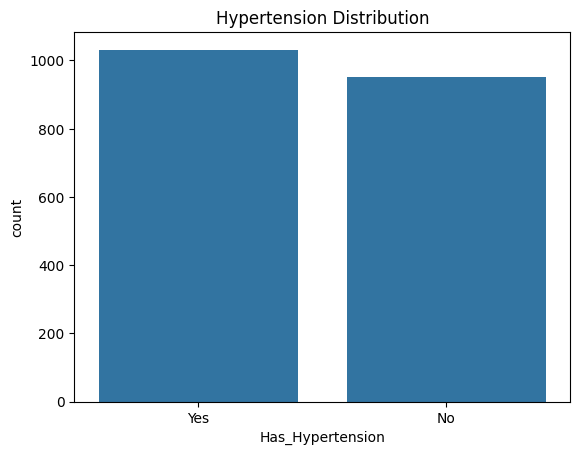

In [ ]:
if 'Has_Hypertension' in df.columns:
    sns.countplot(x='Has_Hypertension', data=df)
    plt.title("Hypertension Distribution")
    plt.show()

##Visualizations

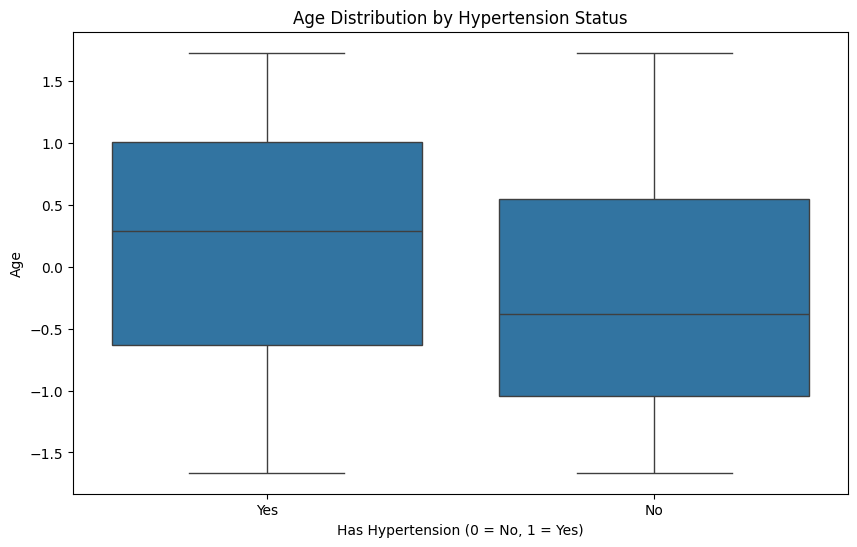

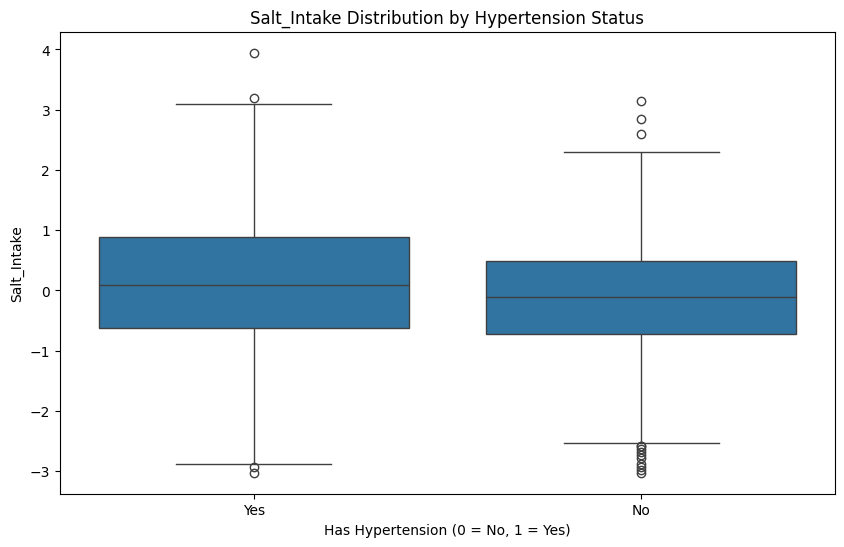

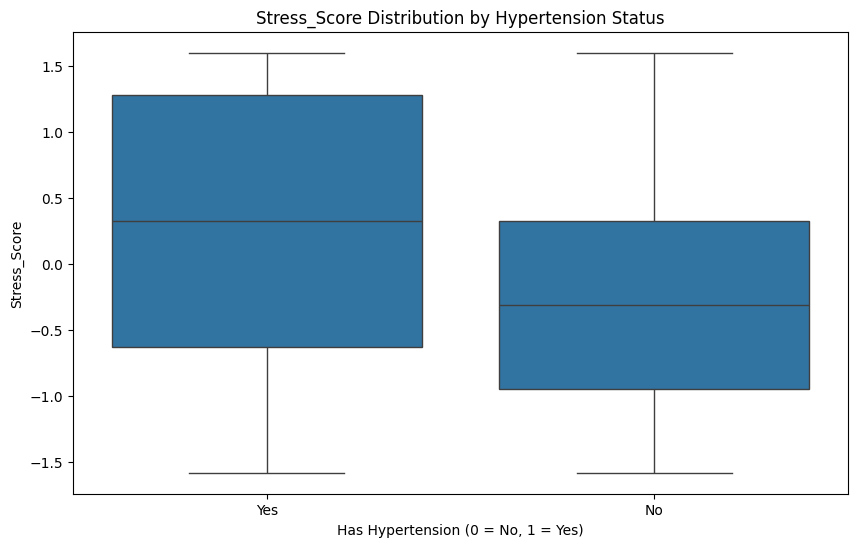

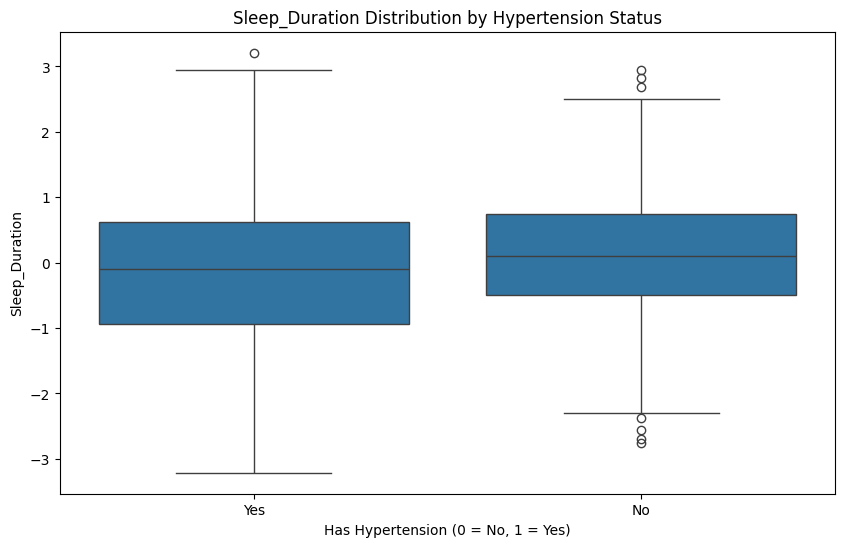

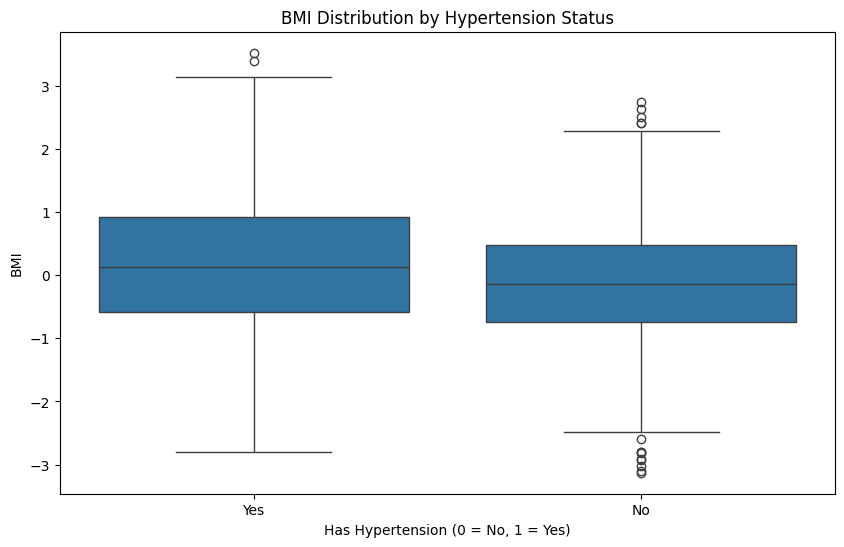

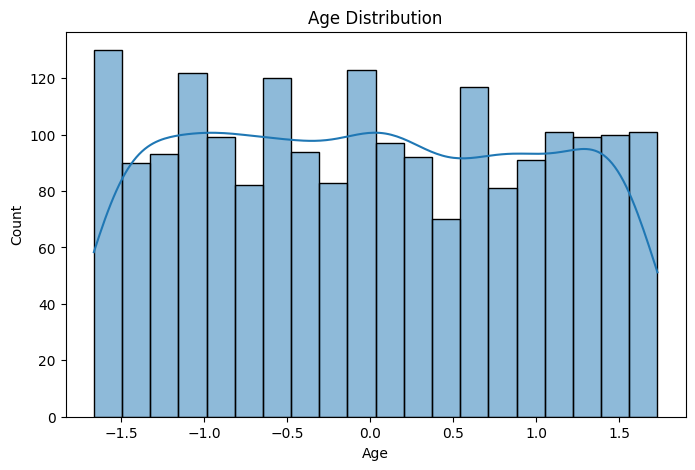

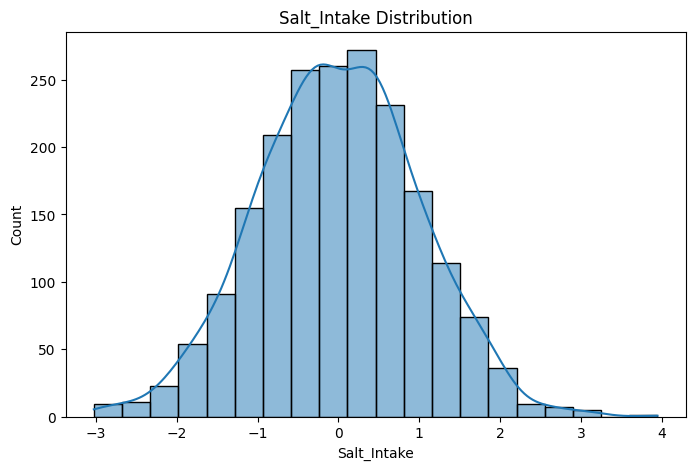

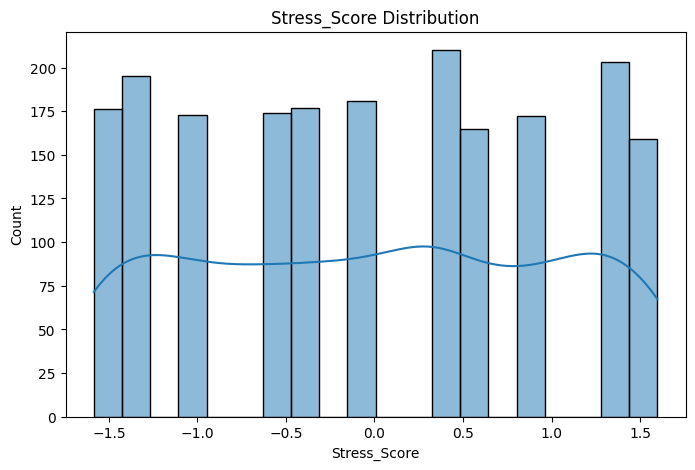

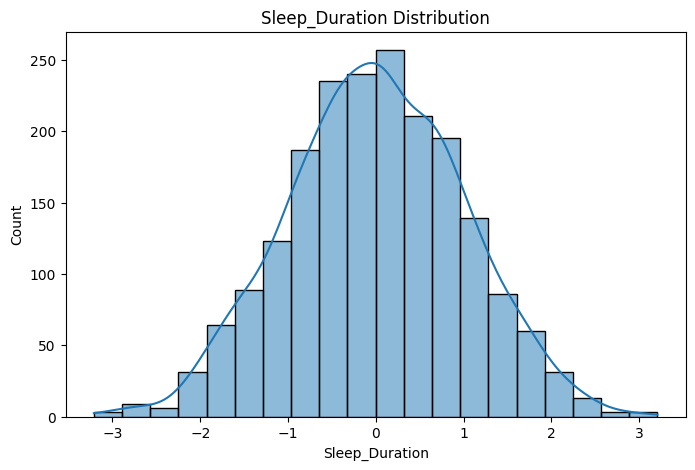

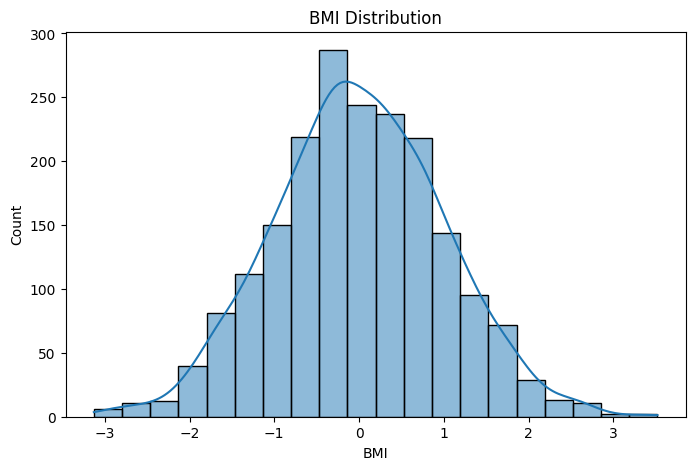

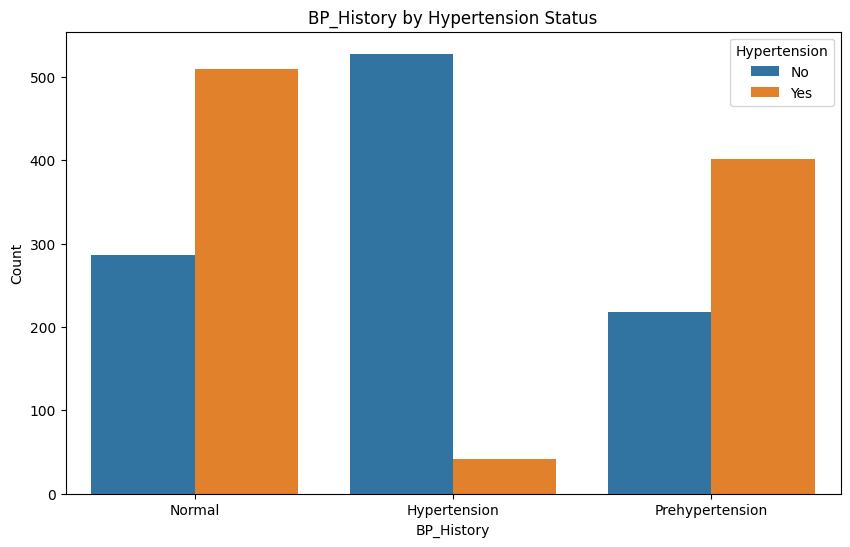

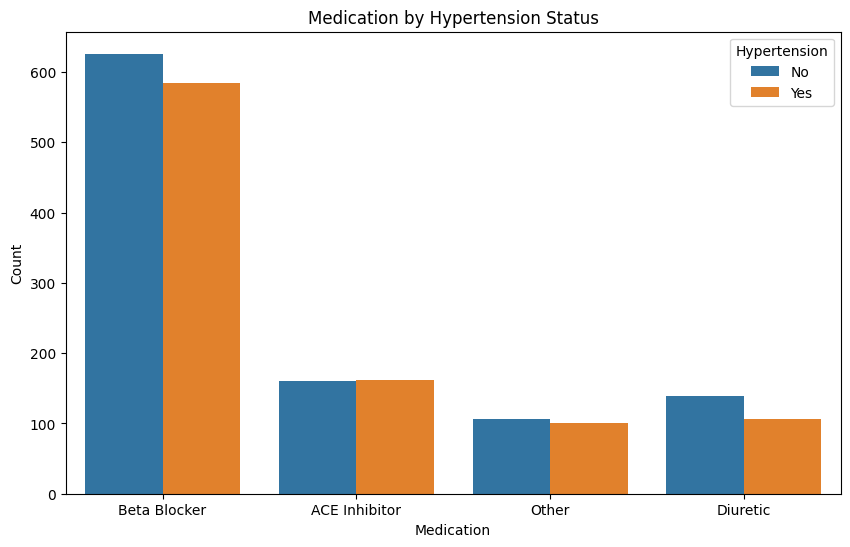

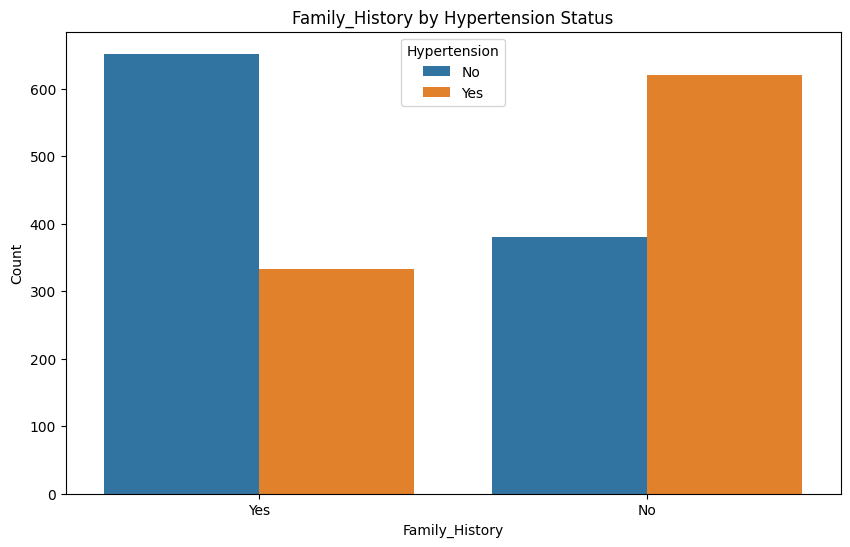

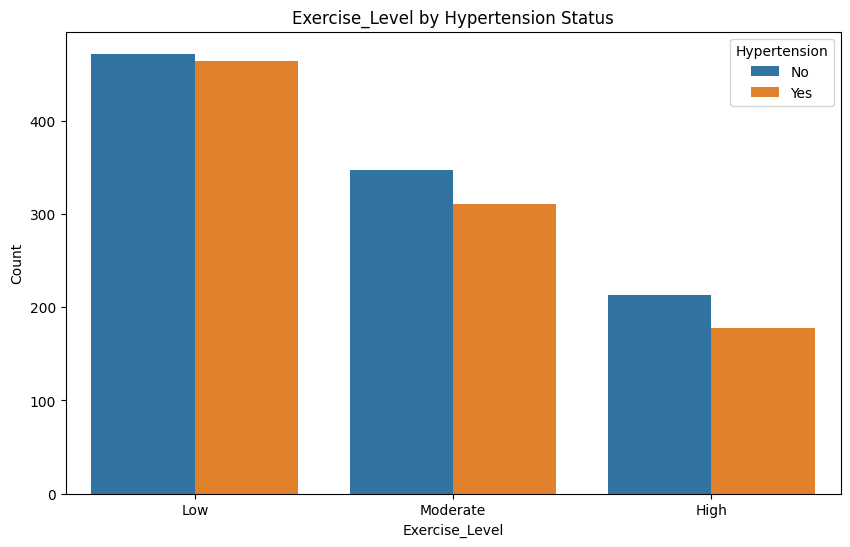

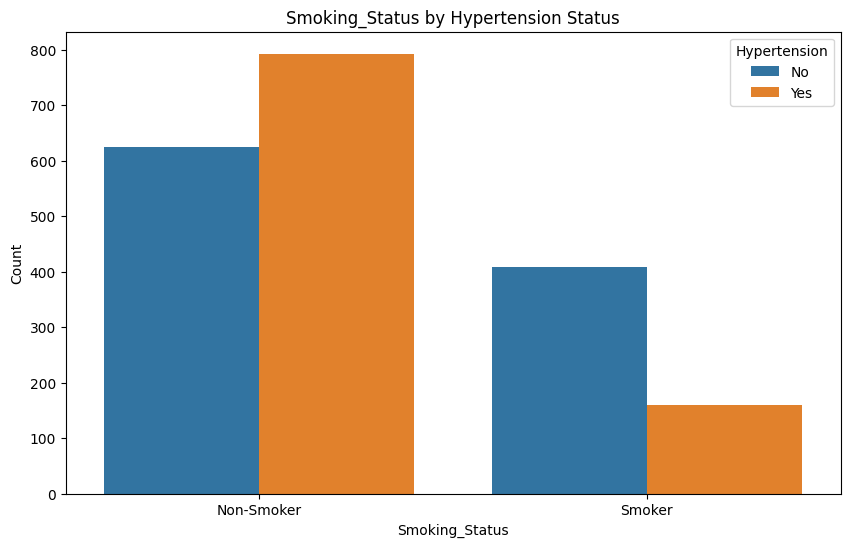

In [ ]:
numeric_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']

for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Has_Hypertension', y=col, data=df)
    plt.title(f'{col} Distribution by Hypertension Status')
    plt.xlabel('Has Hypertension (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

# --------------------
# 2. Histograms for Numeric Features
# --------------------
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

# --------------------
# 3. Countplots for Categorical Features vs Has_Hypertension
# --------------------
categorical_cols = ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Has_Hypertension', data=df)
    plt.title(f'{col} by Hypertension Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Hypertension', labels=['No', 'Yes'])
    plt.show()

##Correlation Heatmap

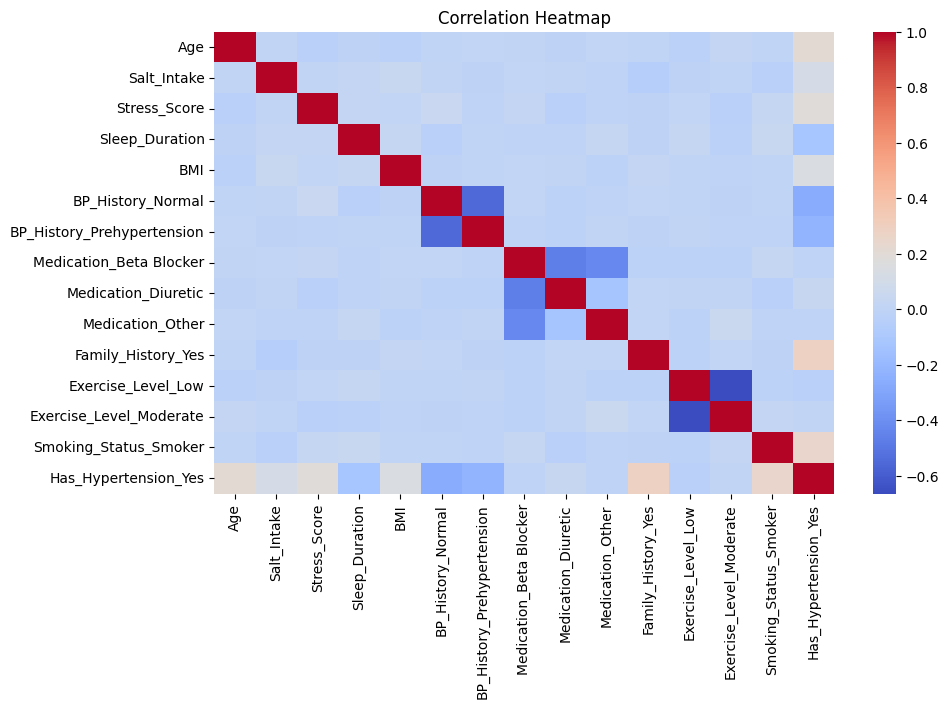

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#Models & Tools

##RandomForest

In [ ]:
from sklearn.model_selection import train_test_split


X = df_encoded.drop('Has_Hypertension_Yes', axis=1)
y = df_encoded['Has_Hypertension_Yes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1588, 14)
Testing set shape: (397, 14)


In [ ]:

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):

        return self.tree

    def predict(self, tree, instance):

        return tree["prediction"]

In [ ]:
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):

        self.tree = {"prediction": y.mode()[0] if not y.empty else 0}
        return self.tree

    def predict(self, tree, instance):

        return tree["prediction"]

class RandomForest:
    def __init__(self, n_estimators=10, max_depth=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        self.feature_importances_ = None

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape
        self.feature_importances_ = np.zeros(n_features)

        for _ in range(self.n_estimators):

            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X.iloc[indices], y.iloc[indices]

            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)


            self.trees.append(tree)

    def predict(self, X):
        final_predictions = []
        for index, row in X.iterrows():
            tree_predictions = [tree.predict(tree.tree, row) for tree in self.trees]

            final_prediction = np.mean(tree_predictions) > 0.5
            final_predictions.append(final_prediction)

        return np.array(final_predictions)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score

X = df_encoded.drop('Has_Hypertension_Yes', axis=1)
y = df_encoded['Has_Hypertension_Yes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


random_forest = RandomForest(n_estimators=25, max_depth=5)
random_forest.fit(X_train, y_train)


y_pred_rf_scr = random_forest.predict(X_test)

accuracy_rf_scr = accuracy_score(y_test, y_pred_rf_scr)
f1_rf_scr = f1_score(y_test, y_pred_rf_scr)
recall_rf_scr = recall_score(y_test, y_pred_rf_scr)


print(f"Random Forest Classifier  Accuracy: {accuracy_rf_scr:.2%}")
print(f"Random Forest Classifier  F1 Score: {f1_rf_scr:.2f}")
print(f"Random Forest Classifier  Recall: {recall_rf_scr:.2f}")

Random Forest Classifier  Accuracy: 51.64%
Random Forest Classifier  F1 Score: 0.68
Random Forest Classifier  Recall: 1.00


##Gradient boosting



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
y_pred_gb = gb_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)

print(f"Gradient Boosting Classifier Accuracy: {accuracy_gb:.2%}")
print(f"Gradient Boosting Classifier F1 Score: {f1_gb:.2f}")
print(f"Gradient Boosting Classifier Recall: {recall_gb:.2f}")

Gradient Boosting Classifier Accuracy: 98.49%
Gradient Boosting Classifier F1 Score: 0.99
Gradient Boosting Classifier Recall: 0.99


##XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score


xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)


accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)

print(f"XGBoost Classifier Accuracy: {accuracy_xgb:.2%}")
print(f"XGBoost Classifier F1 Score: {f1_xgb:.2f}")
print(f"XGBoost Classifier Recall: {recall_xgb:.2f}")

XGBoost Classifier Accuracy: 98.74%
XGBoost Classifier F1 Score: 0.99
XGBoost Classifier Recall: 0.99


##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score


log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)


y_pred_lr = log_reg_model.predict(X_test)


accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.2%}")
print(f"Logistic Regression F1 Score: {f1_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")

Logistic Regression Accuracy: 88.66%
Logistic Regression F1 Score: 0.89
Logistic Regression Recall: 0.88


##K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score


knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)


y_pred_knn = knn_model.predict(X_test)


accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.2%}")
print(f"K-Nearest Neighbors F1 Score: {f1_knn:.2f}")
print(f"K-Nearest Neighbors Recall: {recall_knn:.2f}")

K-Nearest Neighbors Accuracy: 82.37%
K-Nearest Neighbors F1 Score: 0.82
K-Nearest Neighbors Recall: 0.79


##Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)


accuracy_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {accuracy_nb:.2%}")
print(f"Naive Bayes F1 Score: {f1_nb:.2f}")
print(f"Naive Bayes Recall: {recall_nb:.2f}")

Naive Bayes Accuracy: 82.12%
Naive Bayes F1 Score: 0.83
Naive Bayes Recall: 0.84


##Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.2%}")
print(f"Decision Tree F1 Score: {f1_dt:.2f}")
print(f"Decision Tree Recall: {recall_dt:.2f}")

Decision Tree Accuracy: 93.45%
Decision Tree F1 Score: 0.94
Decision Tree Recall: 0.94


In [ ]:
class RandomForest:
    def __init__(self, n_estimators=10, max_depth=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []
        self.feature_importances_ = None

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape
        self.feature_importances_ = np.zeros(n_features)

        for _ in range(self.n_estimators):

            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_sample, y_sample = X.iloc[indices], y.iloc[indices]

            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)



            self.trees.append(tree)

    def predict(self, X):
        final_predictions = []
        for index, row in X.iterrows():
            tree_predictions = [tree.predict(tree.tree, row) for tree in self.trees]

            final_prediction = np.mean(tree_predictions) > 0.5
            final_predictions.append(final_prediction)

        return np.array(final_predictions)

##Result Visualization

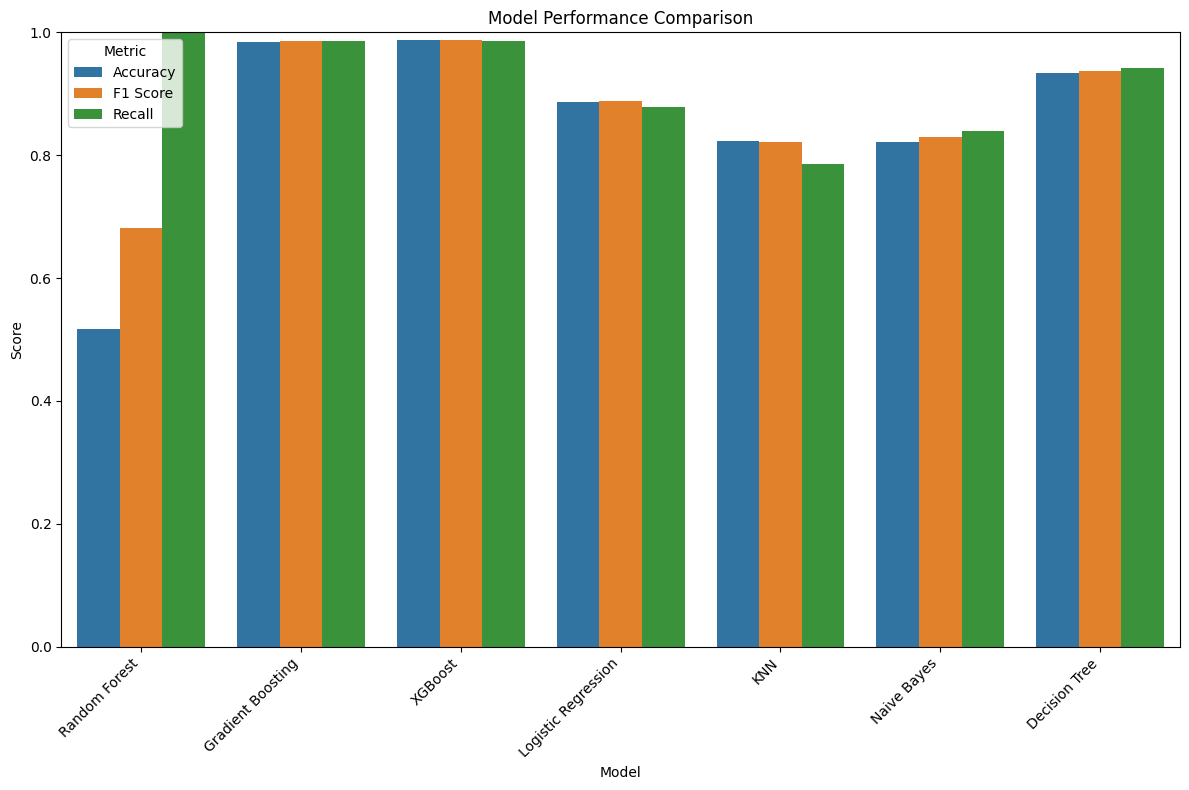

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


metrics = {
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Logistic Regression', 'KNN', 'Naive Bayes', 'Decision Tree'],
    'Accuracy': [accuracy_rf_scr, accuracy_gb, accuracy_xgb, accuracy_lr, accuracy_knn, accuracy_nb, accuracy_dt],
    'F1 Score': [f1_rf_scr, f1_gb, f1_xgb, f1_lr, f1_knn, f1_nb, f1_dt],
    'Recall': [recall_rf_scr, recall_gb, recall_xgb, recall_lr, recall_knn, recall_nb, recall_dt]
}

metrics_df = pd.DataFrame(metrics)

metrics_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')


plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()